In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

In [15]:
response = requests.get("https://zenodo.org/api/records/5063428")
data = response.json()

In [16]:
data['files']

[{'id': '71e8025f-5186-4ed2-a8d5-c62bba3ef2fb',
  'key': 'CLEAN_House4.csv',
  'size': 395763806,
  'checksum': 'md5:efbfab2b04a61fbf7595422f15cacfb1',
  'links': {'self': 'https://zenodo.org/api/records/5063428/files/CLEAN_House4.csv/content'}},
 {'id': '27113878-0bf2-4074-bb2a-70c2da80b43d',
  'key': 'CLEAN_House11.csv',
  'size': 255832544,
  'checksum': 'md5:5b41bae97ab28871fcfe5167b41c0347',
  'links': {'self': 'https://zenodo.org/api/records/5063428/files/CLEAN_House11.csv/content'}},
 {'id': '48e21798-2889-4615-a973-15600fe56db3',
  'key': 'CLEAN_House1.csv',
  'size': 400840083,
  'checksum': 'md5:f5336d80c700f866af0d997ea8d39146',
  'links': {'self': 'https://zenodo.org/api/records/5063428/files/CLEAN_House1.csv/content'}},
 {'id': 'd810f183-40cb-459d-81a5-5c8d4a7af497',
  'key': 'CLEAN_House2.csv',
  'size': 325391201,
  'checksum': 'md5:13957fd139bf8f6ba8bceea36e85bb3d',
  'links': {'self': 'https://zenodo.org/api/records/5063428/files/CLEAN_House2.csv/content'}},
 {'id': '8

In [6]:
df = []
base_path = os.getcwd()
data_path = os.path.join(base_path, "data")
os.makedirs(data_path, exist_ok = True)

In [ ]:
# jeśli nie masz pobranych plików z danymi
for plik in data['files']:
    if plik['key'].endswith('.csv'):
        url = plik['links']['self']
        print(f"{plik['key']}")

    temp_df = pd.read_csv(url)

    sciezka_zapisu = os.path.join(data_path, plik['key'])
    temp_df.to_csv(sciezka_zapisu, index=False)

    df.append(temp_df)

In [7]:
# jak już masz folder data a w nim pobrane dane
df = pd.read_csv(f"{os.path.join(data_path, 'CLEAN_House4.csv')}")

In [8]:
mapping = {
    'Appliance1': 'Fridge_Freezer',
    'Appliance2': 'Chest_Freezer',
    'Appliance3': 'Upright_Freezer',
    'Appliance4': 'Tumble_Dryer',
    'Appliance5': 'Washing_Machine',
    'Appliance6': 'Dishwasher',
    'Appliance7': 'Computer',
    'Appliance8': 'TV',
    'Appliance9': 'Electric_Heater'
}
df.rename(columns=mapping, inplace=True)
df['Time'] = pd.to_datetime(df['Time'])

In [9]:
appliances = ['Fridge_Freezer', 'Chest_Freezer', 'Upright_Freezer',
              'Tumble_Dryer', 'Washing_Machine', 'Dishwasher',
              'Computer', 'TV', 'Electric_Heater']
target_cols = [f'{app}_on' for app in appliances]
for app in appliances:
    threshold = df[app].quantile(0.25)

    df[f'{app}_on'] = np.where(df[app] > threshold, 1, 0)

Dane pełne bez ubytków

### Struktura danych
| Nazwa Kolumny | Urządzenie | Typ Danych | Jednostka | Opis |
| :--- | :--- | :--- | :--- | :--- |
| **Time** | Znacznik czasu | Datetime | YYYY-MM-DD HH:MM:SS | Próbkowanie co ok. 8s. |
| **Unix** | Czas Unix | Integer | Sekundy (s) | Timestamp w formacie POSIX. |
| **Aggregate** | Całkowite zużycie domu | Float | Waty (W) | Główna zmienna wejściowa modelu (Main Meter). |
| **Fridge_Freezer** | Lodówko-zamrażarka | Float | Waty (W) | Praca cykliczna, sterowana termostatem. |
| **Chest_Freezer** | Zamrażarka skrzyniowa | Float | Waty (W) | Stabilne piki mocy podczas pracy sprężarki. |
| **Upright_Freezer** | Zamrażarka pionowa | Float | Waty (W) | Kolejne urządzenie chłodnicze o stałym profilu. |
| **Tumble_Dryer** | Suszarka do ubrań | Float | Waty (W) | Bardzo wysoka moc (>2000W), praca ciągła. |
| **Washing_Machine** | Pralka | Float | Waty (W) | Zmienny profil: grzanie wody vs. praca silnika. |
| **Dishwasher** | Zmywarka | Float | Waty (W) | Charakterystyczne skoki mocy w cyklach grzania. |
| **Computer** | Stanowisko komputerowe | Float | Waty (W) | Zasilacze impulsowe, niski szum tła. |
| **TV** | Stanowisko TV | Float | Waty (W) | Telewizor i sprzęt towarzyszący. |
| **Electric_Heater** | Grzejnik elektryczny | Float | Waty (W) | Obciążenie rezystancyjne, wysoka, stała moc. |

**Źródło danych:** Murray, D., Stankovic, L., & Stankovic, V. (2017). *REFIT Smart Home dataset*. Loughborough University. [DOI: 10.4121/uuid:5bd1068a-6625

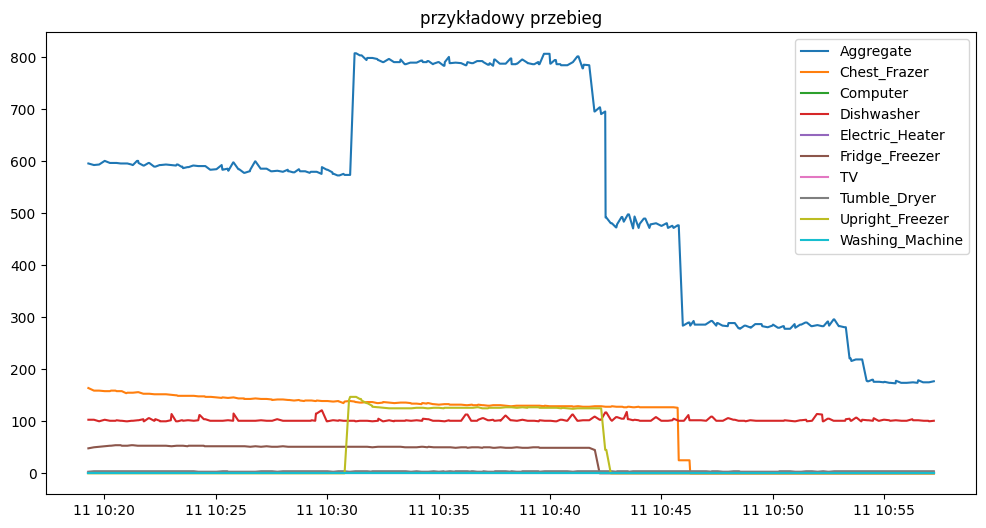

In [10]:
df_small = df.iloc[:400]

plt.figure(figsize=(12, 6))
plt.title("przykładowy przebieg")
plt.plot(df_small['Time'], df_small['Aggregate'], label = 'Aggregate')
plt.plot(df_small['Time'], df_small['Chest_Freezer'], label = 'Chest_Frazer')
plt.plot(df_small['Time'], df_small['Computer'], label = 'Computer')
plt.plot(df_small['Time'], df_small['Dishwasher'], label = 'Dishwasher')
plt.plot(df_small['Time'], df_small['Electric_Heater'], label = 'Electric_Heater')
plt.plot(df_small['Time'], df_small['Fridge_Freezer'], label = 'Fridge_Freezer')
plt.plot(df_small['Time'], df_small['TV'], label = 'TV')
plt.plot(df_small['Time'], df_small['Tumble_Dryer'], label = 'Tumble_Dryer')
plt.plot(df_small['Time'], df_small['Upright_Freezer'], label = 'Upright_Freezer')
plt.plot(df_small['Time'], df_small['Washing_Machine'], label = 'Washing_Machine')
plt.legend()
plt.show()

### Trening set prep

#### Features
| Nazwa Cechy | Opis | Rola w modelu |
| :--- | :--- | :--- |
| **Aggregate** | Bieżący odczyt mocy całkowitej (t) | Główny sygnał wejściowy. |
| **Agg_Lag1, Lag2, Lag3** | Moc z poprzednich 3 odczytów (t-1, t-2, t-3) | Pozwala modelowi dostrzec kształt zbocza (narastanie/spadek). |
| **Power_Delta** | Różnica: $Aggregate(t) - Aggregate(t-1)$ | Kluczowa do wykrywania momentów włączenia/wyłączenia urządzeń. |
| **Roll_Mean_5min** | Średnia krocząca z ostatnich 5 minut | Odfiltrowuje szum i pokazuje poziom bazowy (baseload). |
| **Roll_Std_5min** | Odchylenie standardowe z ostatnich 5 minut | Pomaga odróżnić urządzenia stabilne od tych o zmiennym poborze. |
| **Hour** | Godzina doby (0-23) | Uwzględnia behawiorystykę mieszkańców (np. pranie rzadziej w nocy). |
| **Day_of_Week** | Dzień tygodnia (0-6) | Pozwala wykryć wzorce weekendowe vs. dni robocze. |

#### Targets
| Target (Binarny 0/1) | Urządzenie docelowe | Próg detekcji (ON) |
| :--- | :--- | :--- |
| **Fridge_Freezer_on** | Lodówko-zamrażarka | > 15W |
| **Chest_Freezer_on** | Zamrażarka skrzyniowa | > 15W |
| **Upright_Freezer_on** | Zamrażarka pionowa | > 15W |
| **Tumble_Dryer_on** | Suszarka do ubrań | > 15W |
| **Washing_Machine_on** | Pralka | > 15W |
| **Dishwasher_on** | Zmywarka | > 15W |
| **Computer_on** | Stanowisko komputerowe | > 15W |
| **TV_on** | Stanowisko TV | > 15W |
| **Electric_Heater_on** | Grzejnik elektryczny | > 15W |

---

In [11]:
Train_set = pd.DataFrame()
Train_set['Aggregate'] = df[['Aggregate']]

Train_set['Time'] = df['Time'].dt.hour + df['Time'].dt.minute / 60
Train_set['day_of_week'] = df['Time'].dt.dayofweek

# Czas jako liczba od 0 do 1 (postęp doby)
Train_set['day_progress'] = (df['Time'].dt.hour * 3600 +
                             df['Time'].dt.minute * 60 +
                             df['Time'].dt.second) / 86400

Train_set['agg_lag_1'] = df['Aggregate'].shift(1)
Train_set['agg_lag_2'] = df['Aggregate'].shift(2)
Train_set['agg_lag_3'] = df['Aggregate'].shift(3)

Train_set['power_delta'] = df['Aggregate'].diff()

window_size = 37
Train_set['roll_mean_5min'] = df['Aggregate'].rolling(window=window_size).mean()
Train_set['roll_std_5min'] = df['Aggregate'].rolling(window=window_size).std()

Train_set = Train_set.join(df[target_cols])

In [ ]:
Train_set.info()
print(Train_set.isnull().sum())
Train_set.head()

In [12]:
Train_set = Train_set.dropna()
Train_set.info()
print(Train_set.isnull().sum())
Train_set.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6760475 entries, 36 to 6760510
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Aggregate           int64  
 1   Time                float64
 2   day_of_week         int32  
 3   day_progress        float64
 4   agg_lag_1           float64
 5   agg_lag_2           float64
 6   agg_lag_3           float64
 7   power_delta         float64
 8   roll_mean_5min      float64
 9   roll_std_5min       float64
 10  Fridge_Freezer_on   int64  
 11  Chest_Freezer_on    int64  
 12  Upright_Freezer_on  int64  
 13  Tumble_Dryer_on     int64  
 14  Washing_Machine_on  int64  
 15  Dishwasher_on       int64  
 16  Computer_on         int64  
 17  TV_on               int64  
 18  Electric_Heater_on  int64  
dtypes: float64(8), int32(1), int64(10)
memory usage: 1005.8 MB
Aggregate             0
Time                  0
day_of_week           0
day_progress          0
agg_lag_1             0
agg_lag_2     

,Aggregate,Time,day_of_week,day_progress,agg_lag_1,agg_lag_2,agg_lag_3,power_delta,roll_mean_5min,roll_std_5min,Fridge_Freezer_on,Chest_Freezer_on,Upright_Freezer_on,Tumble_Dryer_on,Washing_Machine_on,Dishwasher_on,Computer_on,TV_on,Electric_Heater_on
36,592,10.383333,4,0.432789,593.0,593.0,594.0,-1.0,594.810811,3.125503,1,1,0,1,0,1,0,0,0
37,594,10.383333,4,0.432812,592.0,593.0,593.0,2.0,594.756757,3.121657,1,1,0,1,0,1,0,0,0
38,594,10.383333,4,0.432847,594.0,592.0,593.0,0.0,594.783784,3.110333,1,1,0,1,0,1,0,0,0
39,590,10.383333,4,0.432951,594.0,594.0,592.0,-4.0,594.675676,3.206366,1,1,0,1,0,1,0,0,0
40,590,10.383333,4,0.432963,590.0,594.0,594.0,0.0,594.378378,3.112264,1,1,0,1,0,1,0,0,0


In [13]:
df_small = Train_set.iloc[:4000000].copy()

In [14]:
X = df_small.drop(columns=target_cols)
y = df_small[target_cols]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Rozmiar treningowy: {X_train.shape}")
print(f"Rozmiar testowy: {X_test.shape}")

Rozmiar treningowy: (3200000, 10)
Rozmiar testowy: (800000, 10)


In [26]:
model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

In [13]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [20]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [27]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [17]:
import joblib

In [ ]:
model_path = 'models'
os.makedirs(model_path, exist_ok=True)

joblib.dump(model, os.path.join(model_path, 'model_nilm_4k_44min.pkl'))

['modele_ml/model_nilm_4k_44min.pkl']

In [18]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix

In [28]:
model = joblib.load('models/model_nilm_house1_4k_44min.pkl')
y_pred = model.predict(X_test)

c:\INNE\GITHUB\NILM-Activity-Recognition\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\INNE\GITHUB\NILM-Activity-Recognition\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [29]:
for i, column in enumerate(target_cols):
    print(f"--- house1 4k dla urządzenia: {column} ---")
    print(classification_report(y_test[column], y_pred[:, i]))
    print("\n")

--- house1 4k dla urządzenia: Fridge_Freezer_on ---
              precision    recall  f1-score   support

           0       0.81      0.69      0.75    652417
           1       0.17      0.28      0.21    147583

    accuracy                           0.62    800000
   macro avg       0.49      0.49      0.48    800000
weighted avg       0.69      0.62      0.65    800000



--- house1 4k dla urządzenia: Chest_Freezer_on ---
              precision    recall  f1-score   support

           0       0.58      0.75      0.65    455822
           1       0.45      0.28      0.34    344178

    accuracy                           0.55    800000
   macro avg       0.52      0.51      0.50    800000
weighted avg       0.53      0.55      0.52    800000



--- house1 4k dla urządzenia: Upright_Freezer_on ---
              precision    recall  f1-score   support

           0       0.67      0.58      0.62    538376
           1       0.32      0.41      0.36    261624

    accuracy          

In [24]:
for i, column in enumerate(target_cols):
    print(f"--- Raport dla urządzenia: {column} ---")
    print(classification_report(y_test[column], y_pred[:, i]))
    print("\n")

--- Raport dla urządzenia: Fridge_Freezer_on ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92    652417
           1       0.84      0.37      0.51    147583

    accuracy                           0.87    800000
   macro avg       0.85      0.67      0.72    800000
weighted avg       0.87      0.87      0.85    800000



--- Raport dla urządzenia: Chest_Freezer_on ---
              precision    recall  f1-score   support

           0       0.87      0.89      0.88    455822
           1       0.85      0.82      0.84    344178

    accuracy                           0.86    800000
   macro avg       0.86      0.86      0.86    800000
weighted avg       0.86      0.86      0.86    800000



--- Raport dla urządzenia: Upright_Freezer_on ---
              precision    recall  f1-score   support

           0       0.86      0.96      0.91    538376
           1       0.89      0.67      0.77    261624

    accuracy                   

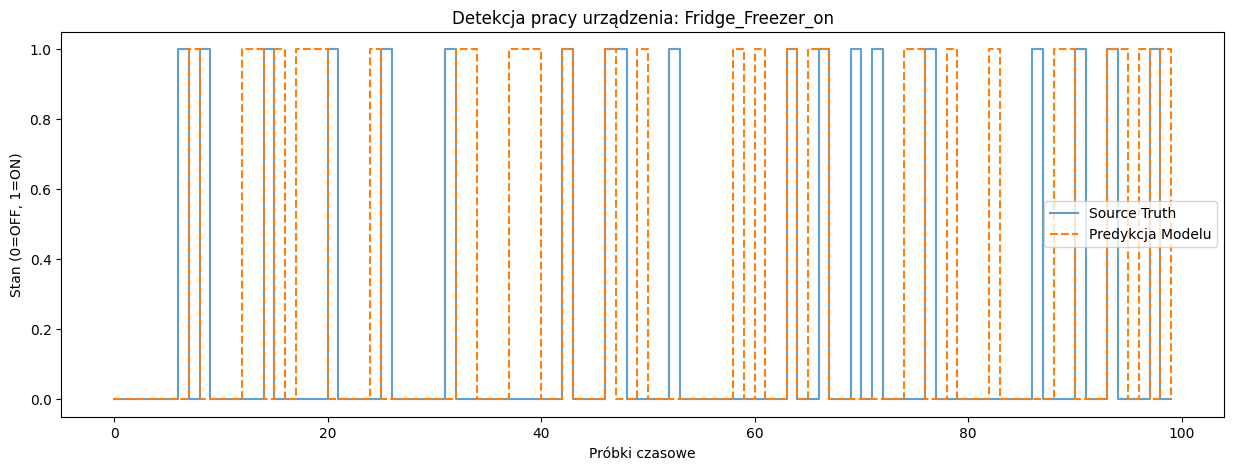

In [ ]:
n_samples = 100
subset_idx = X_test.index[:n_samples]

subset_idx = subset_idx.sort_values()

target_to_plot = 'Fridge_Freezer_on'
col_idx = list(target_cols).index(target_to_plot)

plt.figure(figsize=(15, 5))
plt.step(range(n_samples), y_test.loc[subset_idx, target_to_plot], label='Source Truth', where='post', alpha=0.7)
plt.step(range(n_samples), model.predict(X_test.loc[subset_idx])[:, col_idx], label='Predykcja Modelu', where='post', linestyle='--')

plt.title(f"Detekcja pracy urządzenia: {target_to_plot}")
plt.xlabel("Próbki czasowe")
plt.ylabel("Stan (0=OFF, 1=ON)")
plt.legend()
plt.show()

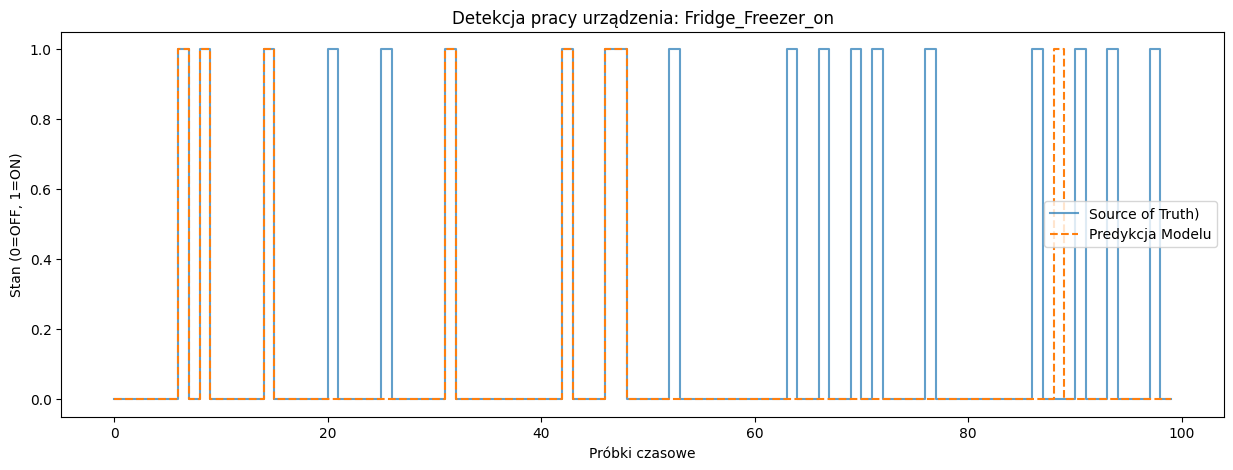

In [ ]:
n_samples = 100
subset_idx = X_test.index[:n_samples]

subset_idx = subset_idx.sort_values()

target_to_plot = 'Fridge_Freezer_on'
col_idx = list(target_cols).index(target_to_plot)

plt.figure(figsize=(15, 5))
plt.step(range(n_samples), y_test.loc[subset_idx, target_to_plot], label='Source of Truth)', where='post', alpha=0.7)
plt.step(range(n_samples), model.predict(X_test.loc[subset_idx])[:, col_idx], label='Predykcja Modelu', where='post', linestyle='--')

plt.title(f"Detekcja pracy urządzenia: {target_to_plot}")
plt.xlabel("Próbki czasowe")
plt.ylabel("Stan (0=OFF, 1=ON)")
plt.legend()
plt.show()